In [1]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
from sklearn.metrics import roc_curve, auc  
import os  

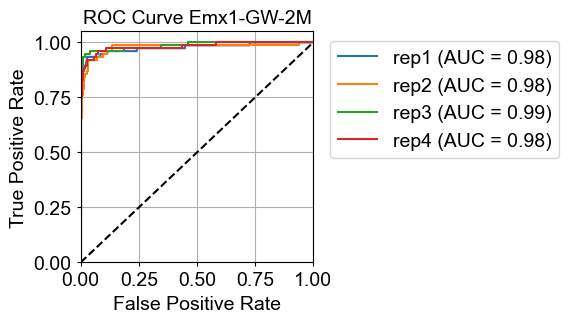

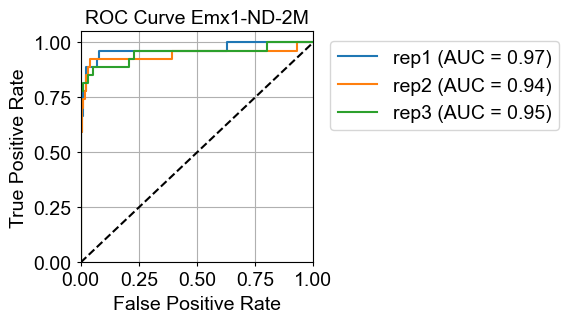

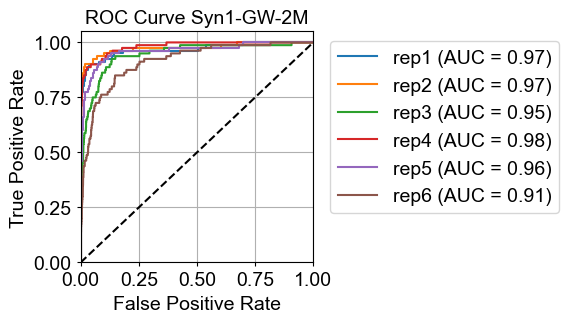

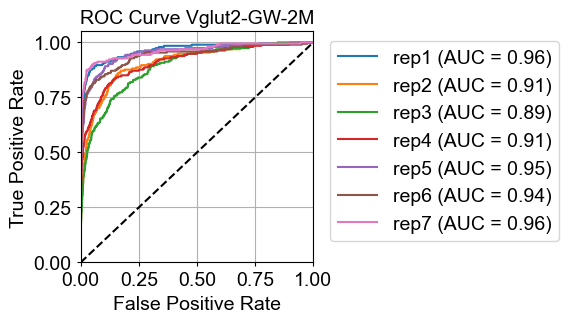

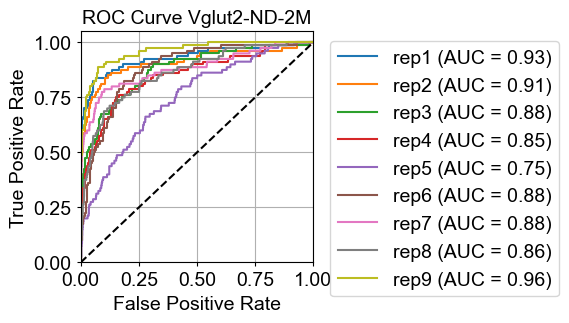

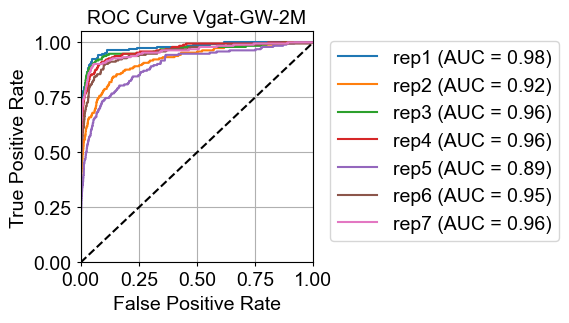

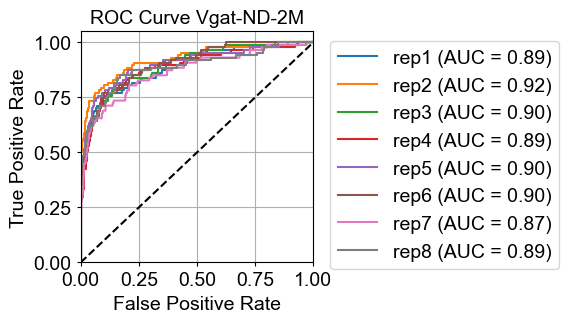

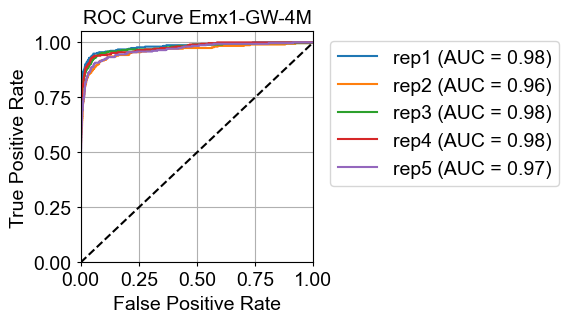

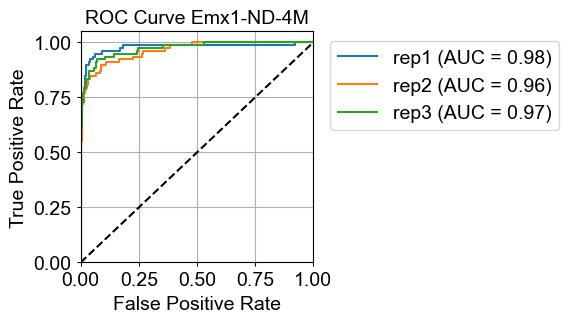

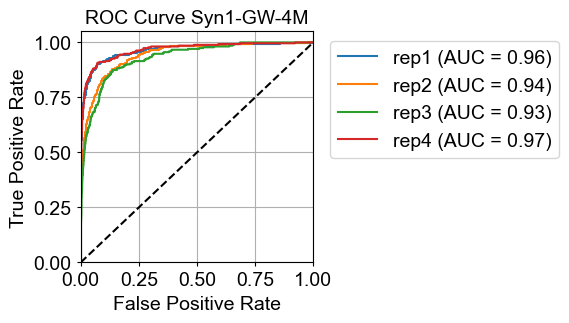

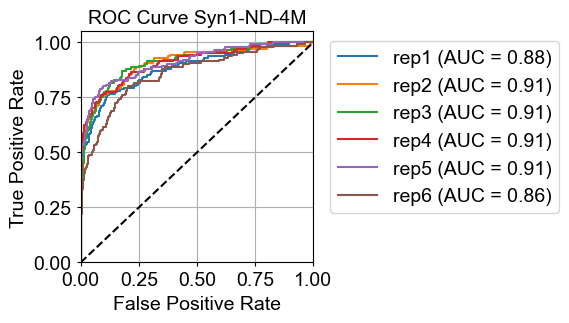

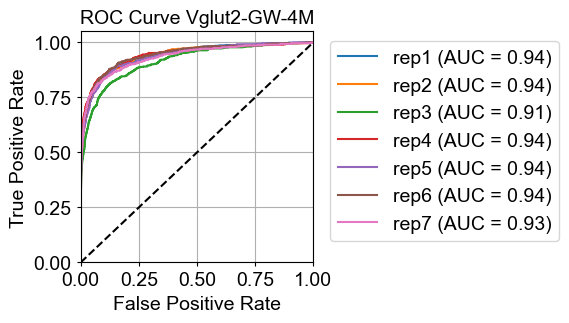

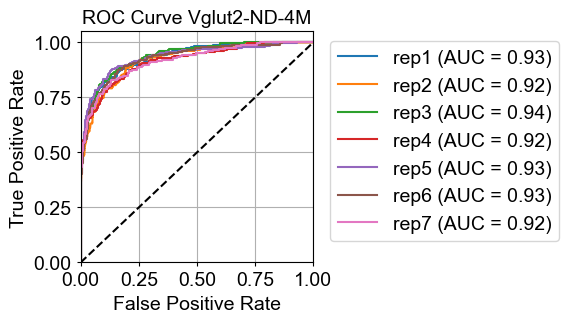

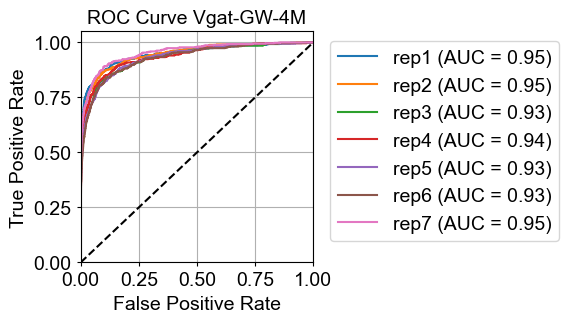

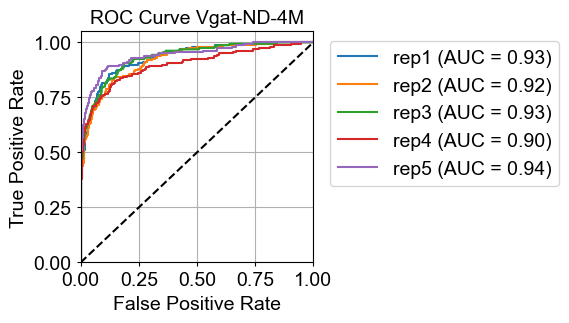

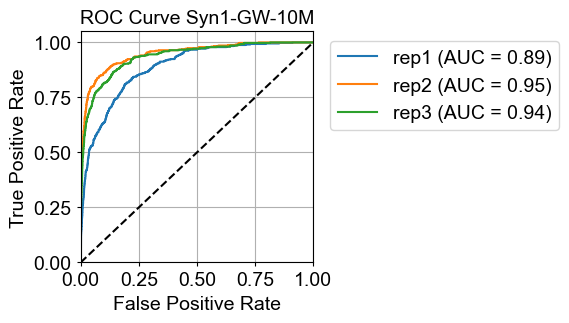

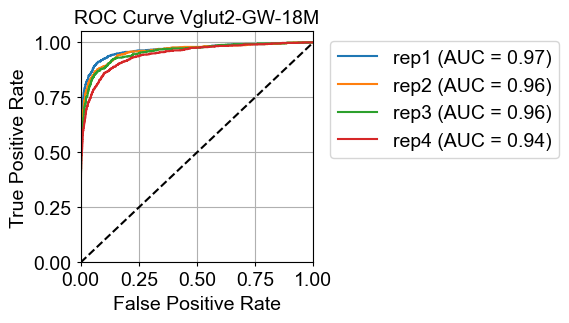

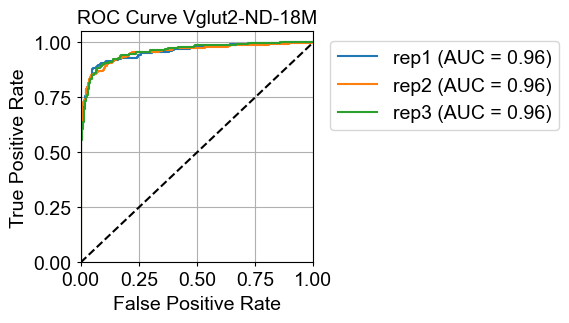

In [2]:
plt.rcParams['font.family'] = 'sans-serif'  
plt.rcParams['font.sans-serif'] = ['Arial']  
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 0.8  
plt.rcParams['xtick.major.width'] = 0.8  
plt.rcParams['ytick.major.width'] = 0.8  
plt.rcParams['xtick.major.size'] = 3  
plt.rcParams['ytick.major.size'] = 3  
plt.rcParams['pdf.fonttype'] = 42  # Ensures text is editable in AI  
plt.rcParams['ps.fonttype'] = 42  

# Step 3: Load screen data from CSV and plot ROC curves  

file_path = '../roc_auc/mageck_output/'
true_pos = '../new_mageck/'
out_path = '../roc_auc/curves/'
times = ['2M', '4M', '10M', '18M']
celltypes = ['Emx1-GW', 'Emx1-ND', 'Syn1-GW', 'Syn1-ND', 'Vglut2-GW', 'Vglut2-ND', 'Vgat-GW', 'Vgat-ND']
for time in times:
    for celltype in celltypes:
        screen = celltype + '-' + time
        screen_names = [i for i in os.listdir(file_path) if screen in i ]
        if len(screen_names) > 0:
            plt.figure(figsize=(3, 3))  
            for i, sample in enumerate(screen_names):  
                # Load the screen data  

                df_true = pd.read_csv(f'{true_pos}{celltype}-all_{time}/{celltype}-all_{time}.gene_summary.txt',sep='\t' )  
                true_positives = df_true[df_true['hits'] == -1]['gene'].tolist()

                df = pd.read_csv(f'{file_path}{sample}/{sample}.gene_summary.txt',sep='\t' )  
                y_true = df['gene'].isin(true_positives).astype(int)  
                y_scores = -df['neg|score'].values  

                # Compute ROC curve and AUC  
                fpr, tpr, _ = roc_curve(y_true, y_scores)  
                roc_auc = auc(fpr, tpr)  

                # Plot ROC curve  
                plt.plot(fpr, tpr, label=f'rep{i+1} (AUC = {roc_auc:.2f})')  
            # Step 4: Plot formatting  
            plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line  
            plt.xlim([0.0, 1.0])  
            plt.ylim([0.0, 1.05])  
            plt.xticks(np.arange(0,1.1,0.25))
            plt.yticks(np.arange(0,1.1,0.25))
            plt.xlabel('False Positive Rate')  
            plt.ylabel('True Positive Rate')  
            plt.title(f'ROC Curve {screen}', fontsize=14)  
            plt.legend(loc='upper right', bbox_to_anchor=(2.1, 1), fontsize=14)  
            plt.grid(which = 'both')  
            plt.savefig(f'{out_path}{screen}_ROC.pdf', bbox_inches = 'tight')